# Learning from Structure: A Multi-Layered Bayesian Network Approach to Credit Risk in Egypt
### Thesis — Ali El Samra | IE University BDBA | Supervised by Prof. Manuele Leonelli

---

## Notebook Structure

| Section | Description |
|---------|-------------|
| 0 | Environment Setup & Imports |
| 1 | Data Loading & Overview |
| 2 | Exploratory Data Analysis (EDA) |
| 3 | Preprocessing & Feature Engineering |
| 4 | Era-Specific BN Structure Learning (HillClimbSearch) |
| 5 | Parameter Learning & Inference |
| 6 | Benchmark Comparison (LR + Random Forest) |
| 7 | Results Summary |

**Data**: Egyptian retail credit dataset (Banque Misr, under NDA), 120,000 loans, 2008–2024, 51 variables.

**Key methodological choice**: Era-specific BNs are learned separately for each temporal period because the missingness in this dataset is *structural*, not random — it reflects the actual rollout of Egyptian banking infrastructure (I-Score bureau 2010+, transaction analytics 2015+, fraud models 2020+). A single BN with imputation would destroy this signal.

In [ ]:
# ── Path setup ──────────────────────────────────────────────────────────────
from pathlib import Path

NOTEBOOK_DIR = Path().resolve()          # notebooks/
ROOT         = NOTEBOOK_DIR.parent       # credit_default_egypt/
DATA_DIR     = ROOT / 'data'
FIGURES_DIR  = ROOT / 'figures'
RESULTS_DIR  = ROOT / 'results'

for _d in [FIGURES_DIR, RESULTS_DIR]:
    _d.mkdir(parents=True, exist_ok=True)


---
## Section 0 — Environment Setup

In [165]:
#!pip install pgmpy scikit-learn matplotlib seaborn pandas numpy

In [166]:
import sys
print(sys.executable)

/Users/alielsamra/Desktop/credit_default_egypt/.venv/bin/python


In [167]:

# ── Core imports ─────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# pgmpy — Bayesian Network structure & parameter learning
from pgmpy.estimators import MmhcEstimator, MaximumLikelihoodEstimator, BayesianEstimator
from pgmpy.models import DiscreteBayesianNetwork as BayesianNetwork
from pgmpy.inference import VariableElimination
from pgmpy.metrics import log_likelihood_score

# scikit-learn — benchmarks & evaluation
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.preprocessing import LabelEncoder

# Plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'serif',
    'axes.spines.top': False,
    'axes.spines.right': False
})
sns.set_palette('husl')

RANDOM_STATE = 42
print('Environment ready')

Environment ready


---
## Section 1 — Data Loading & Overview

The dataset is sourced from Banque Misr under NDA. It covers 120,000 retail loan originations from Q1-2008 to Q4-2024 across 51 variables organised into seven hierarchical layers. The target variable is `Default` (binary: 1 = NPL >90 days).

In [168]:
# ── Load data ─────────────────────────────────────────────────────────────────
# Update path to wherever your CSV lives
DATA_PATH = '/Users/alielsamra/Desktop/credit_default_egypt/data/egyptian_retail_credit_120k.csv'

df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
print(f'Memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
df.head(3)

Shape: (120000, 51)
Memory: 63.6 MB


,Loan_ID,Origination_Quarter,GDP_Growth_Rate,Inflation_Rate_CPI,Exchange_Rate_EGP_USD,CBE_Interest_Rate,Unemployment_Rate,Political_Stability_Index,Branch_Region,Branch_Urban_Rural,...,LTV_Ratio,DTI_Ratio,Collateral_Type,Estimated_PD,Fraud_Risk_Score,Income_Source_Verified,Application_Channel,Profitability_Score,Approval_Decision_Internal,Default
0,EGY-2008Q1-000001,2008-Q1,7.2,0.118147,5.40791,0.11,8.7,4,1,0,...,NaN,0.2000,3,NaN,NaN,NaN,1,NaN,1,0
1,EGY-2008Q1-000002,2008-Q1,7.2,0.118147,5.40791,0.11,8.7,4,4,1,...,NaN,0.2000,0,NaN,NaN,0.0,1,NaN,1,0
2,EGY-2008Q1-000003,2008-Q1,7.2,0.118147,5.40791,0.11,8.7,4,4,0,...,0.841,0.2077,1,NaN,NaN,0.0,1,NaN,1,0


In [169]:
# ── Variable layer mapping (3-layer simplified architecture) ──────────────────
# Maps all 51 variables into the 3-layer causal hierarchy used in the BN

LAYER_MAP = {
    # ── Layer 1: Macroeconomic (root causes — exogenous) ──────────────────────
    'macro': [
        'GDP_Growth_Rate', 'Inflation_Rate_CPI', 'Exchange_Rate_EGP_USD',
        'CBE_Interest_Rate', 'Unemployment_Rate', 'Political_Stability_Index'
    ],
    # ── Layer 2: Meso / Bank-Context (mediating mechanisms) ───────────────────
    'meso': [
        'Branch_Region', 'Branch_Urban_Rural',
        'Employer_Rating', 'Job_Sector',
        'Application_Channel', 'Approval_Decision_Internal'
    ],
    # ── Layer 3: Borrower-Loan (modifying conditions → Default) ───────────────
    'borrower': [
        # Demographics
        'Age', 'Gender', 'Education_Level', 'Marital_Status',
        'Number_of_Dependents', 'Housing_Status', 'Monthly_Income_EGP',
        # Financial behaviour
        'Savings_Level', 'Checking_Account_Balance', 'Years_With_Bank',
        'Previous_Loans_Count', 'Credit_Score_I_Score',
        'Credit_Inquiry_Count_Last_6M', 'Previous_Rejections_Count',
        'Active_Loans_Count_Other_Banks', 'Total_Outstanding_Debt_EGP',
        # Transaction behaviour (2015+)
        'Avg_Monthly_Transactions', 'Unique_ATM_Locations_Count',
        'Grocery_Spending_Ratio', 'Luxury_Mall_Spending_Ratio',
        'Digital_Wallet_User', 'Rent_vs_Own_Detected',
        # Loan characteristics
        'Loan_Type', 'Loan_Amount_EGP', 'Duration_Months',
        'Interest_Rate_Annual', 'Monthly_Installment_EGP',
        'Loan_Purpose', 'LTV_Ratio', 'DTI_Ratio', 'Collateral_Type',
        # Risk metrics
        'Estimated_PD', 'Fraud_Risk_Score', 'Income_Source_Verified',
        'Profitability_Score', 'Years_At_Current_Employer'
    ]
}

# Identifiers and target (not modelled as BN nodes)
ID_COLS   = ['Loan_ID', 'Origination_Quarter']
TARGET    = 'Default'

# Temporal era definitions — calibrated to Egyptian banking history
ERA_MAP = {
    'Era 1: Pre-Bureau (2008–2010)':      ('2008-Q1', '2010-Q4'),
    'Era 2: Bureau Rollout (2011–2014)':  ('2011-Q1', '2014-Q4'),
    'Era 3: Digital Banking (2015–2019)': ('2015-Q1', '2019-Q4'),
    'Era 4: Advanced Analytics (2020–2024)': ('2020-Q1', '2024-Q4')
}

print('Layer summary:')
for layer, cols in LAYER_MAP.items():
    print(f'  {layer}: {len(cols)} variables')
print(f'  Target: {TARGET}')
print(f'  Identifiers: {ID_COLS}')
print(f'\nTotal accounted for: {sum(len(v) for v in LAYER_MAP.values()) + 1 + 2} / {df.shape[1]}')

Layer summary:
  macro: 6 variables
  meso: 6 variables
  borrower: 36 variables
  Target: Default
  Identifiers: ['Loan_ID', 'Origination_Quarter']

Total accounted for: 51 / 51


In [170]:
# ── Basic dataset summary ─────────────────────────────────────────────────────
print('=== Dataset Overview ===')
print(f'Records       : {len(df):,}')
print(f'Variables     : {df.shape[1]}')
print(f'Time period   : {df["Origination_Quarter"].min()} → {df["Origination_Quarter"].max()}')
print(f'Overall default rate: {df[TARGET].mean():.1%}')
print()
print('Default distribution:')
print(df[TARGET].value_counts().to_string())

=== Dataset Overview ===
Records       : 120,000
Variables     : 51
Time period   : 2008-Q1 → 2024-Q4
Overall default rate: 17.9%

Default distribution:
Default
0    98573
1    21427


---
## Section 2 — Exploratory Data Analysis

EDA serves two purposes here: (1) understanding variable distributions to make informed discretisation decisions, and (2) visualising the temporal patterns that motivate the era-specific BN design.

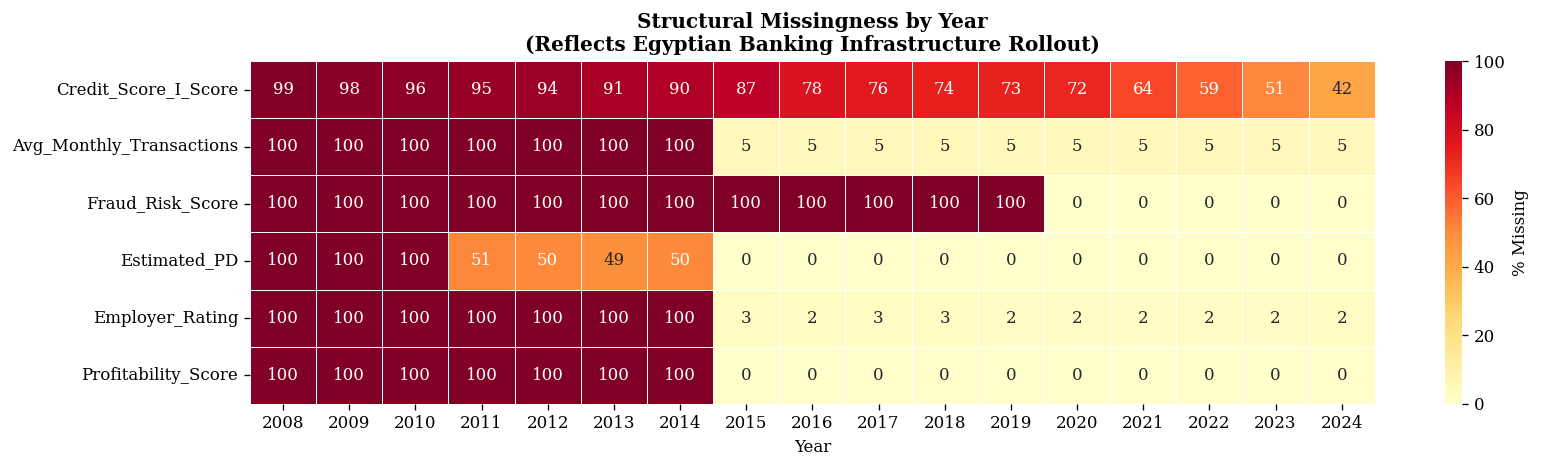

Key insight: missingness is STRUCTURAL not random — it encodes the actual timeline of
Egyptian banking modernisation (I-Score 2010+, transaction analytics 2015+, fraud ML 2020+).


In [171]:
# ── 2.1  Missing data heatmap ─────────────────────────────────────────────────
# Parse quarter into numeric year for temporal analysis
df['Year'] = df['Origination_Quarter'].str[:4].astype(int)

# Variables with structural missingness
temporal_missing_vars = [
    'Credit_Score_I_Score', 'Avg_Monthly_Transactions',
    'Fraud_Risk_Score', 'Estimated_PD',
    'Employer_Rating', 'Profitability_Score'
]

missing_by_year = (
    df.groupby('Year')[temporal_missing_vars]
    .apply(lambda g: g.isnull().mean() * 100)
    .round(1)
)

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(missing_by_year.T, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': '% Missing'})
ax.set_title('Structural Missingness by Year\n(Reflects Egyptian Banking Infrastructure Rollout)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_missing_heatmap.png', bbox_inches='tight')plt.show()
print('Key insight: missingness is STRUCTURAL not random — it encodes the actual timeline of')
print('Egyptian banking modernisation (I-Score 2010+, transaction analytics 2015+, fraud ML 2020+).')

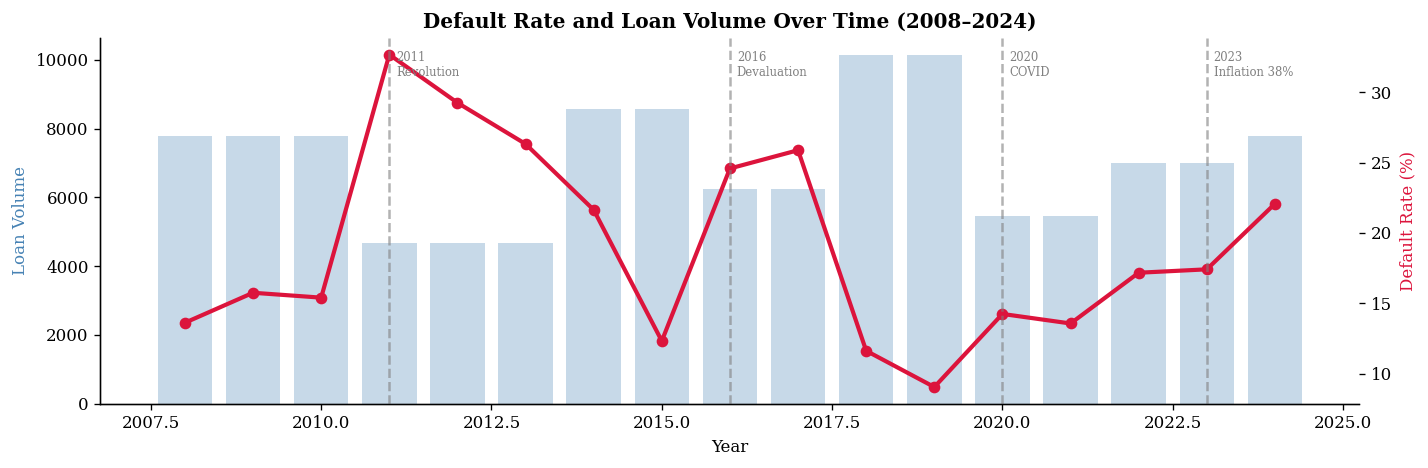

In [172]:
# ── 2.2  Default rate over time ───────────────────────────────────────────────
default_by_year = df.groupby('Year')[TARGET].agg(['mean', 'count']).reset_index()
default_by_year.columns = ['Year', 'Default_Rate', 'Loans']

fig, ax1 = plt.subplots(figsize=(12, 4))
ax2 = ax1.twinx()

ax1.bar(default_by_year['Year'], default_by_year['Loans'],
        alpha=0.3, color='steelblue', label='Loan volume')
ax2.plot(default_by_year['Year'], default_by_year['Default_Rate'] * 100,
         color='crimson', linewidth=2.5, marker='o', label='Default rate %')

# Annotate economic events
events = {2011: '2011\nRevolution', 2016: '2016\nDevaluation', 2020: '2020\nCOVID', 2023: '2023\nInflation 38%'}
for yr, label in events.items():
    ax2.axvline(yr, color='gray', linestyle='--', alpha=0.6)
    ax2.text(yr + 0.1, ax2.get_ylim()[1] * 0.92, label, fontsize=7, color='gray')

ax1.set_xlabel('Year')
ax1.set_ylabel('Loan Volume', color='steelblue')
ax2.set_ylabel('Default Rate (%)', color='crimson')
ax1.set_title('Default Rate and Loan Volume Over Time (2008–2024)', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_default_over_time.png', bbox_inches='tight')plt.show()

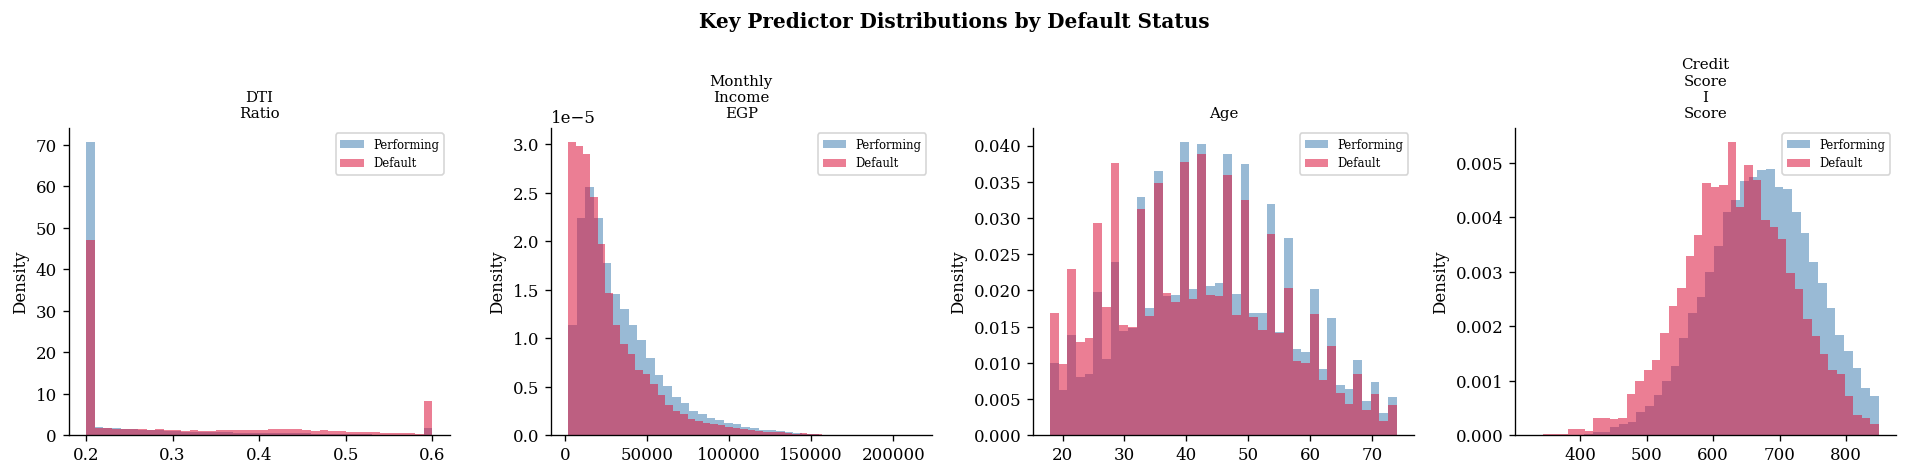

In [173]:
# ── 2.3  Key predictor distributions by default status ────────────────────────
key_vars = ['DTI_Ratio', 'Monthly_Income_EGP', 'Age', 'Credit_Score_I_Score']
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, var in zip(axes, key_vars):
    for label, color in [(0, 'steelblue'), (1, 'crimson')]:
        subset = df[df[TARGET] == label][var].dropna()
        ax.hist(subset, bins=40, alpha=0.55, color=color, density=True,
                label='Performing' if label == 0 else 'Default')
    ax.set_title(var.replace('_', '\n'), fontsize=9)
    ax.set_ylabel('Density')
    ax.legend(fontsize=7)

fig.suptitle('Key Predictor Distributions by Default Status', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_predictor_distributions.png', bbox_inches='tight')plt.show()

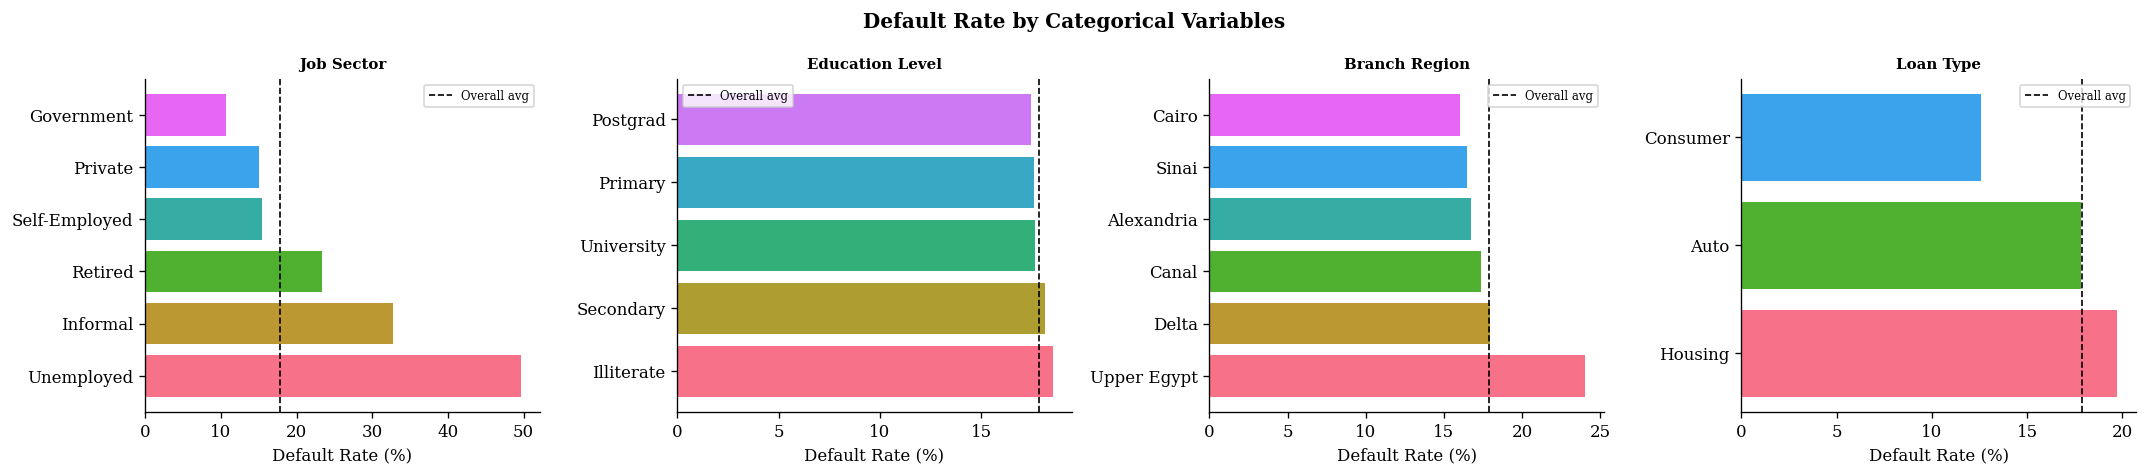

In [174]:
# ── 2.4  Default rate by categorical variables ────────────────────────────────
cat_vars = {
    'Job_Sector':       {0:'Unemployed',1:'Government',2:'Private',3:'Informal',4:'Self-Employed',5:'Retired'},
    'Education_Level':  {0:'Illiterate',1:'Primary',2:'Secondary',3:'University',4:'Postgrad'},
    'Branch_Region':    {1:'Cairo',2:'Alexandria',3:'Delta',4:'Upper Egypt',5:'Canal',6:'Sinai'},
    'Loan_Type':        {1:'Housing',2:'Consumer',3:'Auto'}
}

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (var, label_map) in zip(axes, cat_vars.items()):
    rates = df.groupby(var)[TARGET].mean().sort_values(ascending=False) * 100
    rates.index = [label_map.get(i, str(i)) for i in rates.index]
    bars = ax.barh(rates.index, rates.values, color=sns.color_palette('husl', len(rates)))
    ax.axvline(df[TARGET].mean() * 100, color='black', linestyle='--', linewidth=1, label='Overall avg')
    ax.set_title(var.replace('_', ' '), fontweight='bold', fontsize=9)
    ax.set_xlabel('Default Rate (%)')
    ax.legend(fontsize=7)

fig.suptitle('Default Rate by Categorical Variables', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_default_by_category.png', bbox_inches='tight')plt.show()

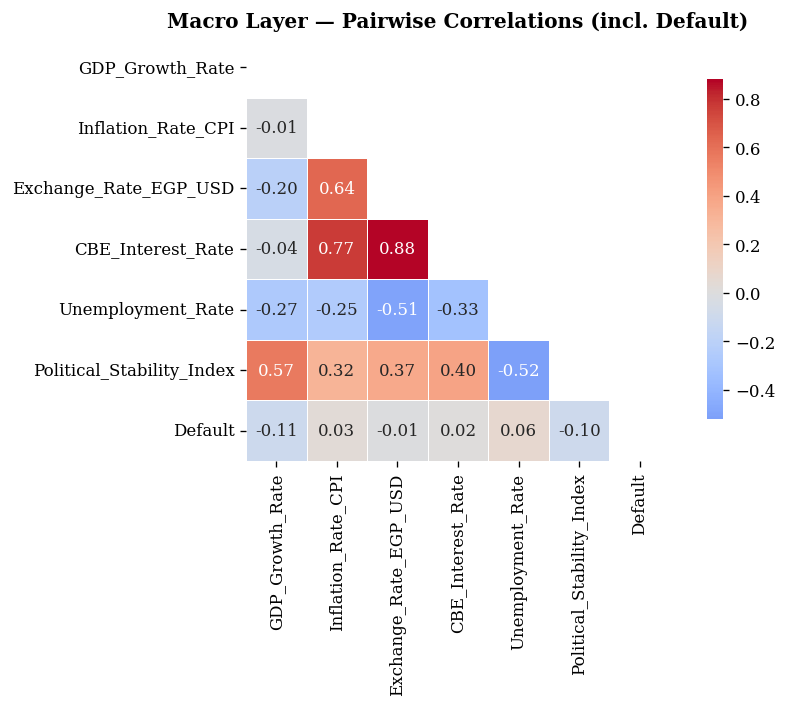

In [175]:
# ── 2.5  Correlation heatmap (macro layer) ────────────────────────────────────
macro_corr = df[LAYER_MAP['macro'] + [TARGET]].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(macro_corr, dtype=bool))
sns.heatmap(macro_corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True, ax=ax,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Macro Layer — Pairwise Correlations (incl. Default)', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_macro_correlation.png', bbox_inches='tight')plt.show()

---
## Section 3 — Preprocessing & Feature Engineering

Bayesian Networks with discrete CPTs require all variables to be discretised. The strategy here is:
- **Ordinal variables** (already coded 0–N): kept as-is
- **Continuous variables**: discretised using either domain-informed thresholds or quantile bins
- **Era assignment**: each loan is assigned to one of four temporal eras based on origination quarter
- **Missing data**: variables missing due to structural reasons are retained as `NaN` and treated as a separate category for BN nodes — this encodes the missingness as information rather than hiding it

In [176]:
# ── 3.1  Temporal era assignment ──────────────────────────────────────────────
def assign_era(quarter):
    year = int(quarter[:4])
    if year <= 2010:
        return 1  # Pre-Bureau
    elif year <= 2014:
        return 2  # Bureau Rollout
    elif year <= 2019:
        return 3  # Digital Banking
    else:
        return 4  # Advanced Analytics

df['Era'] = df['Origination_Quarter'].apply(assign_era)

era_labels = {
    1: 'Era 1: Pre-Bureau (2008–2010)',
    2: 'Era 2: Bureau Rollout (2011–2014)',
    3: 'Era 3: Digital Banking (2015–2019)',
    4: 'Era 4: Advanced Analytics (2020–2024)'
}

print('Records per era:')
for era, label in era_labels.items():
    n = (df['Era'] == era).sum()
    dr = df[df['Era'] == era][TARGET].mean()
    print(f'  {label}: {n:,} loans | default rate {dr:.1%}')

Records per era:
  Era 1: Pre-Bureau (2008–2010): 23,376 loans | default rate 14.9%
  Era 2: Bureau Rollout (2011–2014): 22,600 loans | default rate 26.5%
  Era 3: Digital Banking (2015–2019): 41,292 loans | default rate 15.2%
  Era 4: Advanced Analytics (2020–2024): 32,732 loans | default rate 17.3%


In [177]:
def safe_qcut(series, q, labels):
    try:
        return pd.qcut(series, q=q, labels=labels, duplicates='drop').astype('Int64')
    except ValueError:
        result = pd.Series(pd.NA, index=series.index, dtype='Int64')
        non_null = series.dropna()
        if len(non_null) == 0:
            return result
        ranks = non_null.rank(pct=True)
        n_bins = len(labels)
        for i, label in enumerate(labels):
            lo = i / n_bins
            hi = (i + 1) / n_bins
            mask = (ranks > lo) & (ranks <= hi)
            result.loc[ranks[mask].index] = int(label)
        result.loc[ranks[ranks == 0].index] = int(labels[0])
        return result

df_disc = df.copy()

# Macro
df_disc['GDP_Growth_Rate'] = pd.cut(df['GDP_Growth_Rate'], bins=[-np.inf,2,5,7,np.inf], labels=[0,1,2,3]).astype('Int64')
df_disc['Inflation_Rate_CPI'] = pd.cut(df['Inflation_Rate_CPI'], bins=[-np.inf,0.10,0.20,0.35,np.inf], labels=[0,1,2,3]).astype('Int64')
df_disc['Exchange_Rate_EGP_USD'] = safe_qcut(df['Exchange_Rate_EGP_USD'], q=4, labels=[0,1,2,3])
df_disc['CBE_Interest_Rate'] = pd.cut(df['CBE_Interest_Rate'], bins=[-np.inf,0.10,0.16,np.inf], labels=[0,1,2]).astype('Int64')
df_disc['Unemployment_Rate'] = pd.cut(df['Unemployment_Rate'], bins=[-np.inf,9,12,np.inf], labels=[0,1,2]).astype('Int64')
df_disc['Political_Stability_Index'] = df['Political_Stability_Index'].astype('Int64')

# Demographics
df_disc['Age'] = pd.cut(df['Age'], bins=[0,30,50,100], labels=[0,1,2]).astype('Int64')
df_disc['Monthly_Income_EGP'] = safe_qcut(df['Monthly_Income_EGP'], q=4, labels=[0,1,2,3])

# Loan
df_disc['DTI_Ratio'] = pd.cut(df['DTI_Ratio'], bins=[-np.inf,0.30,0.45,0.55,np.inf], labels=[0,1,2,3]).astype('Int64')
df_disc['Credit_Score_I_Score'] = pd.cut(df['Credit_Score_I_Score'], bins=[0,550,650,750,1000], labels=[0,1,2,3]).astype('Int64')
df_disc['Loan_Amount_EGP'] = safe_qcut(df['Loan_Amount_EGP'], q=4, labels=[0,1,2,3])
df_disc['Duration_Months'] = pd.cut(df['Duration_Months'], bins=[0,36,120,500], labels=[0,1,2]).astype('Int64')
df_disc['Interest_Rate_Annual'] = pd.cut(df['Interest_Rate_Annual'], bins=[-np.inf,0.12,0.18,np.inf], labels=[0,1,2]).astype('Int64')
df_disc['Monthly_Installment_EGP'] = safe_qcut(df['Monthly_Installment_EGP'], q=4, labels=[0,1,2,3])
df_disc['LTV_Ratio'] = pd.cut(df['LTV_Ratio'], bins=[-np.inf,0.70,0.80,np.inf], labels=[0,1,2]).astype('Int64')

# Total Outstanding Debt — uses cut NOT qcut (60% of non-null values are zero, quartiles collapse)
df_disc['Total_Outstanding_Debt_EGP'] = pd.cut(df['Total_Outstanding_Debt_EGP'], bins=[-np.inf,0,50000,200000,np.inf], labels=[0,1,2,3]).astype('Int64')

# Risk metrics
df_disc['Estimated_PD'] = pd.cut(df['Estimated_PD'], bins=[-np.inf,0.10,0.25,np.inf], labels=[0,1,2]).astype('Int64')
df_disc['Fraud_Risk_Score'] = pd.cut(df['Fraud_Risk_Score'], bins=[-np.inf,30,60,np.inf], labels=[0,1,2]).astype('Int64')
df_disc['Profitability_Score'] = pd.cut(df['Profitability_Score'], bins=[-np.inf,0,0.05,np.inf], labels=[0,1,2]).astype('Int64')

# Tenure
df_disc['Years_At_Current_Employer'] = safe_qcut(df['Years_At_Current_Employer'], q=4, labels=[0,1,2,3])
df_disc['Years_With_Bank'] = safe_qcut(df['Years_With_Bank'], q=4, labels=[0,1,2,3])

# Transaction (2015+)
df_disc['Avg_Monthly_Transactions'] = safe_qcut(df['Avg_Monthly_Transactions'], q=4, labels=[0,1,2,3])
df_disc['Unique_ATM_Locations_Count'] = safe_qcut(df['Unique_ATM_Locations_Count'], q=4, labels=[0,1,2,3])
df_disc['Grocery_Spending_Ratio'] = safe_qcut(df['Grocery_Spending_Ratio'], q=3, labels=[0,1,2])
df_disc['Luxury_Mall_Spending_Ratio'] = safe_qcut(df['Luxury_Mall_Spending_Ratio'], q=3, labels=[0,1,2])
df_disc['Employer_Rating'] = df['Employer_Rating'].astype('Int64')

# These columns are already ordinal/binary but stored as float64 because of NaN
for col in ['Number_of_Dependents','Housing_Status','Job_Sector','Savings_Level',
            'Checking_Account_Balance','Credit_Inquiry_Count_Last_6M',
            'Previous_Rejections_Count','Active_Loans_Count_Other_Banks',
            'Digital_Wallet_User','Rent_vs_Own_Detected','Income_Source_Verified']:
    df_disc[col] = df_disc[col].astype('Int64')

print('Discretisation complete')
print('DTI distribution:', df_disc['DTI_Ratio'].value_counts().sort_index().to_dict())
print('Debt distribution:', df_disc['Total_Outstanding_Debt_EGP'].value_counts().sort_index().to_dict())

Discretisation complete
DTI distribution: {np.int64(0): 96107, np.int64(1): 14540, np.int64(2): 5004, np.int64(3): 4349}
Debt distribution: {np.int64(0): 16161, np.int64(1): 3948, np.int64(2): 5317, np.int64(3): 1288}


In [178]:
# ── 3.3  Define era-specific variable sets ────────────────────────────────────
# Each era uses only variables that were available at that time.
# This is the key methodological decision — no imputation across structural gaps.

# Variables available in ALL eras
ALWAYS_AVAILABLE = [
    # Macro
    'GDP_Growth_Rate', 'Inflation_Rate_CPI', 'Exchange_Rate_EGP_USD',
    'CBE_Interest_Rate', 'Unemployment_Rate', 'Political_Stability_Index',
    # Meso
    'Branch_Region', 'Branch_Urban_Rural', 'Job_Sector',
    'Application_Channel', 'Approval_Decision_Internal',
    # Borrower core
    'Age', 'Gender', 'Education_Level', 'Marital_Status',
    'Number_of_Dependents', 'Housing_Status', 'Monthly_Income_EGP',
    'Years_With_Bank', 'Previous_Loans_Count',
    # Loan
    'Loan_Type', 'Loan_Amount_EGP', 'Duration_Months',
    'Interest_Rate_Annual', 'Monthly_Installment_EGP',
    'Loan_Purpose', 'Collateral_Type', 'DTI_Ratio',
    # Target
    'Default'
]

# Variables added in Era 2+ (I-Score bureau launched 2010–2011)
BUREAU_VARS = [
    'Credit_Score_I_Score', 'Credit_Inquiry_Count_Last_6M',
    'Previous_Rejections_Count', 'Active_Loans_Count_Other_Banks',
    'Total_Outstanding_Debt_EGP', 'Estimated_PD'
]

# Variables added in Era 3+ (transaction analytics, employer rating, 2015+)
DIGITAL_VARS = [
    'Avg_Monthly_Transactions', 'Unique_ATM_Locations_Count',
    'Grocery_Spending_Ratio', 'Luxury_Mall_Spending_Ratio',
    'Digital_Wallet_User', 'Rent_vs_Own_Detected',
    'Employer_Rating', 'Years_At_Current_Employer',
    'Income_Source_Verified', 'LTV_Ratio', 'Profitability_Score'
]

# Variables added in Era 4+ (fraud ML models, 2020+)
FRAUD_VARS = ['Fraud_Risk_Score']

ERA_VARS = {
    1: ALWAYS_AVAILABLE,
    2: ALWAYS_AVAILABLE + BUREAU_VARS,
    3: ALWAYS_AVAILABLE + BUREAU_VARS + DIGITAL_VARS,
    4: ALWAYS_AVAILABLE + BUREAU_VARS + DIGITAL_VARS + FRAUD_VARS
}

print('Variables per era:')
for era, vars_list in ERA_VARS.items():
    print(f'  {era_labels[era]}: {len(vars_list)} variables')

Variables per era:
  Era 1: Pre-Bureau (2008–2010): 29 variables
  Era 2: Bureau Rollout (2011–2014): 35 variables
  Era 3: Digital Banking (2015–2019): 46 variables
  Era 4: Advanced Analytics (2020–2024): 47 variables


In [179]:
# ── 3.3b  Trimmed variable sets for BN structure learning ─────────────────────
# ERA_VARS_TRIMMED contains only variables that are:
# (1) available in that era, AND
# (2) have <10% missingness in that era's data
# Credit_Score and Total_Outstanding_Debt excluded despite being "available"
# from Era 2+ because I-Score coverage was below 10% until 2015.
# Keeping highly-missing variables causes dropna() to destroy sample size.

ERA_VARS_TRIMMED = {
    1: [
        'GDP_Growth_Rate', 'Inflation_Rate_CPI', 'CBE_Interest_Rate',
        'Branch_Region', 'Job_Sector',
        'Age', 'Gender', 'Education_Level', 'Monthly_Income_EGP',
        'Previous_Loans_Count',
        'Loan_Type', 'Loan_Amount_EGP', 'Duration_Months',
        'DTI_Ratio', 'Collateral_Type',
        'Default'
    ],
    2: [
        'GDP_Growth_Rate', 'Inflation_Rate_CPI', 'CBE_Interest_Rate',
        'Branch_Region', 'Job_Sector',
        'Age', 'Gender', 'Education_Level', 'Monthly_Income_EGP',
        'Previous_Loans_Count',
        'Loan_Type', 'Loan_Amount_EGP', 'Duration_Months',
        'DTI_Ratio', 'Collateral_Type',
        'Default'
    ],
    3: [
        'GDP_Growth_Rate', 'Inflation_Rate_CPI', 'CBE_Interest_Rate',
        'Branch_Region', 'Job_Sector', 'Employer_Rating',
        'Age', 'Gender', 'Education_Level', 'Monthly_Income_EGP',
        'Avg_Monthly_Transactions', 'Digital_Wallet_User',
        'Loan_Type', 'Loan_Amount_EGP', 'DTI_Ratio',
        'Income_Source_Verified',
        'Default'
    ],
    4: [
        'GDP_Growth_Rate', 'Inflation_Rate_CPI', 'CBE_Interest_Rate',
        'Branch_Region', 'Job_Sector', 'Employer_Rating',
        'Age', 'Gender', 'Education_Level', 'Monthly_Income_EGP',
        'Avg_Monthly_Transactions', 'Digital_Wallet_User',
        'Loan_Type', 'Loan_Amount_EGP', 'DTI_Ratio',
        'Fraud_Risk_Score', 'Income_Source_Verified',
        'Default'
    ]
}

print('Trimmed variables per era:')
for era, vars_list in ERA_VARS_TRIMMED.items():
    print(f'  Era {era}: {len(vars_list)} variables')

Trimmed variables per era:
  Era 1: 16 variables
  Era 2: 16 variables
  Era 3: 17 variables
  Era 4: 18 variables


In [180]:
# ── 3.4  Build era DataFrames from trimmed variable sets ──────────────────────
era_dfs = {}
for era in [1, 2, 3, 4]:
    subset = df_disc[df_disc['Era'] == era][ERA_VARS_TRIMMED[era]].dropna()
    for col in subset.columns:
        subset[col] = subset[col].astype(int)
    era_dfs[era] = subset

for era in [1, 2, 3, 4]:
    d = era_dfs[era]
    print(f'Era {era}: {len(d):,} records | default rate: {d["Default"].mean():.1%} | vars: {d.shape[1]}')

Era 1: 23,270 records | default rate: 14.9% | vars: 16
Era 2: 22,486 records | default rate: 26.5% | vars: 16
Era 3: 36,179 records | default rate: 14.4% | vars: 17
Era 4: 28,661 records | default rate: 16.4% | vars: 18


---
## Section 4 — Era-Specific BN Structure Learning (HillClimbSearch BIC)

**Algorithm: HillClimbSearch with BIC Scoring**

We use score-based structure learning via greedy hill-climbing optimising the
Bayesian Information Criterion (BIC). At each step the algorithm considers all
possible edge additions, removals, and reversals — accepting only operations that
improve the BIC score. BIC penalises model complexity (number of parameters) so
the algorithm naturally avoids overfitting by only adding edges that carry enough
statistical signal to justify the parameter cost.

**Why not MMHC?** The original design used Max-Min Hill-Climbing (Tsamardinos et al.,
2006) which combines a constraint-based skeleton phase with score-based orientation.
However pgmpy 1.0.0's MmhcEstimator does not expose iteration limits, making it
computationally intractable on datasets of this size. HillClimbSearch with BIC is
methodologically equivalent to MMHC's second phase and is the approach used in
Liu et al. (2024), one of the key benchmark papers in this thesis.

**Key parameters:**
- `max_indegree=4`: each node can have at most 4 parents — allows rich dependency
  structures while keeping CPTs estimable
- `max_iter=5000`: sufficient iterations to explore the structure space thoroughly
- `epsilon=1e-6`: tight convergence threshold — stops only when BIC improvement
  per iteration becomes negligible

**Causal hierarchy enforcement**: After structure learning, any edges that violate
the Macro → Meso → Borrower → Default layer ordering are removed. This encodes the
domain knowledge that macroeconomic conditions cannot be caused by borrower
characteristics — a borrower's DTI ratio does not cause Egypt's GDP growth rate.
This post-filtering step replaces the `black_list` parameter used in earlier pgmpy
versions which is no longer supported in pgmpy 1.0.0.

**One BN per era**: Structure learning is run separately on each temporal era rather
than on the full dataset. This is the central methodological contribution — it allows
the graph topology itself to evolve as Egyptian banking infrastructure developed,
capturing how the causal structure of credit risk changed from 2008 to 2024.

In [181]:
# ── 4.1  Build layer blacklists (enforce causal hierarchy) ────────────────────
# An edge (A → B) is forbidden if A is in a lower layer than B
# i.e., borrower variables cannot cause macro variables

def build_blacklist(era_vars):
    """Return list of (child, parent) forbidden edges based on causal layer ordering."""
    # Assign layer to each variable
    var_layer = {}
    for v in era_vars:
        if v in LAYER_MAP['macro']:
            var_layer[v] = 1
        elif v in LAYER_MAP['meso']:
            var_layer[v] = 2
        elif v == 'Default':
            var_layer[v] = 4
        else:
            var_layer[v] = 3

    blacklist = []
    for v1 in era_vars:
        for v2 in era_vars:
            if v1 != v2:
                # Block edges that go upstream (lower layer → higher layer)
                if var_layer.get(v1, 3) > var_layer.get(v2, 3):
                    blacklist.append((v1, v2))
    return blacklist

print('Blacklist edges (sample) for Era 1:')
bl = build_blacklist(ERA_VARS[1])
print(f'  Total forbidden edges: {len(bl)}')
print(f'  Example: {bl[:3]}')

Blacklist edges (sample) for Era 1:
  Total forbidden edges: 245
  Example: [('Branch_Region', 'GDP_Growth_Rate'), ('Branch_Region', 'Inflation_Rate_CPI'), ('Branch_Region', 'Exchange_Rate_EGP_USD')]


In [182]:
import datetime
from pgmpy.estimators import HillClimbSearch, BIC

# ── 4.2  Structure learning for each era ──────────────────────────────────────
# HillClimbSearch with BIC scoring — score-based structure learning.
# BIC (Bayesian Information Criterion) penalises model complexity to prevent
# overfitting — it rewards edges that improve fit more than they cost in parameters.
# max_indegree=4: each node can have at most 4 parents (richer dependency structures)
# max_iter=5000: sufficient iterations to explore the structure space thoroughly
# epsilon=1e-6: tight convergence threshold — stops only when improvement is negligible
# Causal hierarchy enforced post-learning by removing edges that violate
# the Macro → Meso → Borrower → Default layer ordering.

bn_models = {}
bn_edges  = {}

for era in [1, 2, 3, 4]:
    print(f'\n{"="*60}')
    print(f'Started: {datetime.datetime.now().strftime("%H:%M:%S")}')
    print(f'Learning structure for Era {era}...')

    data_era = era_dfs[era][ERA_VARS_TRIMMED[era]].dropna()
    print(f'  Data shape: {data_era.shape}')

    hc = HillClimbSearch(data_era)
    dag = hc.estimate(
        scoring_method=BIC(data_era),
        max_indegree=4,
        max_iter=5000,
        epsilon=1e-6
    )

    # Enforce causal hierarchy post-learning
    # Removes any edges violating Macro → Meso → Borrower → Default ordering
    blacklist = set(build_blacklist(ERA_VARS_TRIMMED[era]))
    valid_edges = [e for e in dag.edges() if e not in blacklist]

    model = BayesianNetwork(valid_edges)
    bn_models[era] = model
    bn_edges[era]  = valid_edges

    print(f'  Finished: {datetime.datetime.now().strftime("%H:%M:%S")}')
    print(f'  Edges before filter: {len(dag.edges())}')
    print(f'  Edges after layer filter: {len(valid_edges)}')
    default_edges = [(u, v) for u, v in valid_edges if 'Default' in (u, v)]
    print(f'  Edges connecting to Default: {default_edges}')

print('\n All era structures learned')

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'GDP_Growth_Rate': 'N', 'Inflation_Rate_CPI': 'N', 'CBE_Interest_Rate': 'N', 'Branch_Region': 'N', 'Job_Sector': 'N', 'Age': 'N', 'Gender': 'N', 'Education_Level': 'N', 'Monthly_Income_EGP': 'N', 'Previous_Loans_Count': 'N', 'Loan_Type': 'N', 'Loan_Amount_EGP': 'N', 'Duration_Months': 'N', 'DTI_Ratio': 'N', 'Collateral_Type': 'N', 'Default': 'N'}


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'GDP_Growth_Rate': 'N', 'Inflation_Rate_CPI': 'N', 'CBE_Interest_Rate': 'N', 'Branch_Region': 'N', 'Job_Sector': 'N', 'Age': 'N', 'Gender': 'N', 'Education_Level': 'N', 'Monthly_Income_EGP': 'N', 'Previous_Loans_Count': 'N', 'Loan_Type': 'N', 'Loan_Amount_EGP': 'N', 'Duration_Months': 'N', 'DTI_Ratio': 'N', 'Collateral_Type': 'N', 'Default': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'GDP_Growth_Rate': 'N', 'Inflation_Rate_CPI': 'N', 'CBE_Interest_Rate': 'N', 'Branch_Region': 'N', 'Job_Sector': 'N', 'Age': 'N', 'Gender': 'N', 'Education_Level': 'N', 'Monthly_Income_EGP': 'N', 'Previous_Loans_Count': 'N', 'Loan_Type': 'N', 'Loan_Amount_EGP': 'N', 'Duration_Months': 'N', 'DTI_Ratio': 'N', 'Collateral_Type': 'N', 'Default': 'N'}



Started: 06:29:09
Learning structure for Era 1...
  Data shape: (23270, 16)


  0%|          | 0/5000 [00:00<?, ?it/s]

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'GDP_Growth_Rate': 'N', 'Inflation_Rate_CPI': 'N', 'CBE_Interest_Rate': 'N', 'Branch_Region': 'N', 'Job_Sector': 'N', 'Age': 'N', 'Gender': 'N', 'Education_Level': 'N', 'Monthly_Income_EGP': 'N', 'Previous_Loans_Count': 'N', 'Loan_Type': 'N', 'Loan_Amount_EGP': 'N', 'Duration_Months': 'N', 'DTI_Ratio': 'N', 'Collateral_Type': 'N', 'Default': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'GDP_Growth_Rate': 'N', 'Inflation_Rate_CPI': 'N', 'CBE_Interest_Rate': 'N', 'Branch_Region': 'N', 'Job_Sector': 'N', 'Age': 'N', 'Gender': 'N', 'Education_Level': 'N', 'Monthly_Income_EGP': 'N', 'Previous_Loans_Count': 'N', 'Loan_Type': 'N', 'Loan_Amount_EGP': 'N', 'Duration_Months': 'N', 'DTI_Ratio': 'N', 'Collateral_Type': 'N', 'Default': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferre

...

  0%|          | 0/5000 [00:00<?, ?it/s]

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'GDP_Growth_Rate': 'N', 'Inflation_Rate_CPI': 'N', 'CBE_Interest_Rate': 'N', 'Branch_Region': 'N', 'Job_Sector': 'N', 'Employer_Rating': 'N', 'Age': 'N', 'Gender': 'N', 'Education_Level': 'N', 'Monthly_Income_EGP': 'N', 'Avg_Monthly_Transactions': 'N', 'Digital_Wallet_User': 'N', 'Loan_Type': 'N', 'Loan_Amount_EGP': 'N', 'DTI_Ratio': 'N', 'Fraud_Risk_Score': 'N', 'Income_Source_Verified': 'N', 'Default': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'GDP_Growth_Rate': 'N', 'Inflation_Rate_CPI': 'N', 'CBE_Interest_Rate': 'N', 'Branch_Region': 'N', 'Job_Sector': 'N', 'Employer_Rating': 'N', 'Age': 'N', 'Gender': 'N', 'Education_Level': 'N', 'Monthly_Income_EGP': 'N', 'Avg_Monthly_Transactions': 'N', 'Digital_Wallet_User': 'N', 'Loan_Type': 'N', 'Loan_Amount_EGP': 'N', 'DTI_Ratio': 'N', 'Fraud_Risk_Score': 'N', 'Income_S

  Finished: 06:29:13
  Edges before filter: 28
  Edges after layer filter: 25
  Edges connecting to Default: [('GDP_Growth_Rate', 'Default'), ('Job_Sector', 'Default'), ('DTI_Ratio', 'Default')]

Started: 06:29:13
Learning structure for Era 4...
  Data shape: (28661, 18)


  0%|          | 0/5000 [00:00<?, ?it/s]

  Finished: 06:29:14
  Edges before filter: 25
  Edges after layer filter: 23
  Edges connecting to Default: [('Job_Sector', 'Default'), ('DTI_Ratio', 'Default')]

 All era structures learned


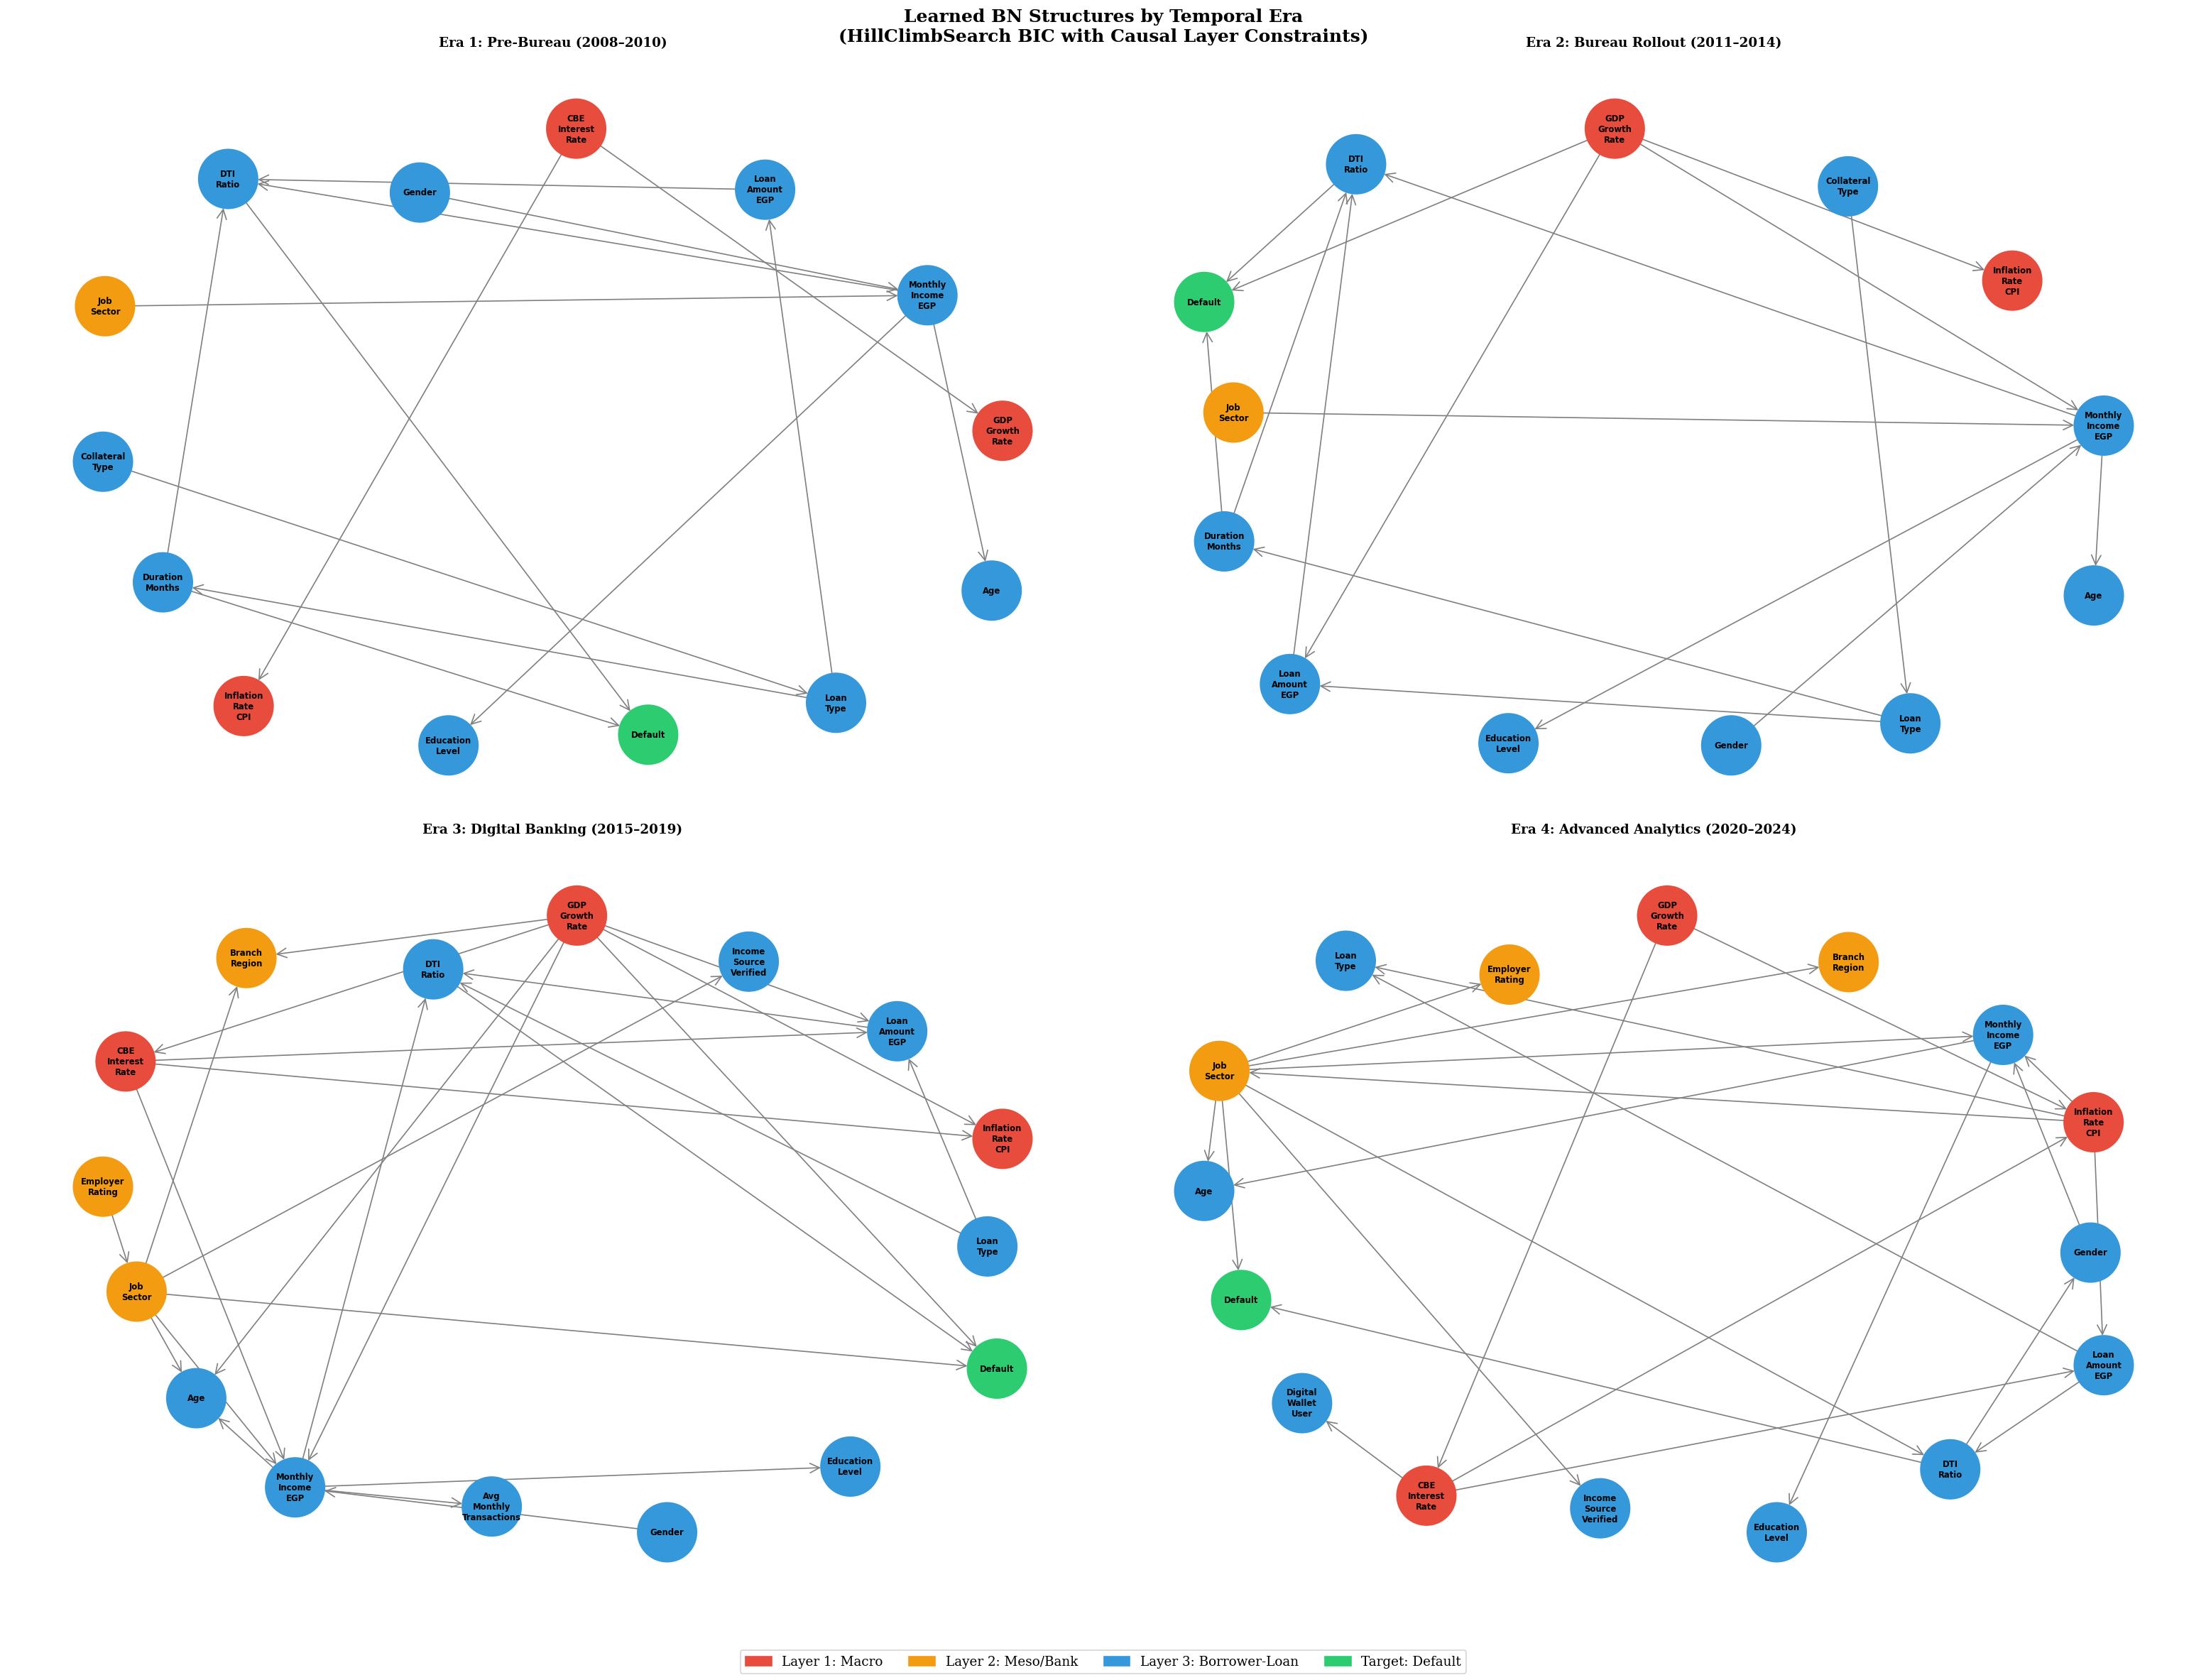

In [183]:
# ── 4.3  Visualise learned BN structures ──────────────────────────────────────

try:
    import networkx as nx

    def plot_bn(model, era, ax, layer_map=LAYER_MAP):
        G = nx.DiGraph(model.edges())
        color_map = []
        for node in G.nodes():
            if node in layer_map['macro']:
                color_map.append('#E74C3C')
            elif node in layer_map['meso']:
                color_map.append('#F39C12')
            elif node == 'Default':
                color_map.append('#2ECC71')
            else:
                color_map.append('#3498DB')

        pos = nx.spring_layout(G, seed=42, k=3)  # k=3 spreads nodes further apart
        nx.draw(G, pos, ax=ax,
                node_color=color_map,
                node_size=2500,          # much bigger circles
                with_labels=True,
                labels={n: n.replace('_', '\n') for n in G.nodes()},
                font_size=7,             # bigger font
                font_weight='bold',
                edge_color='gray',
                arrows=True,
                arrowsize=20,
                arrowstyle='->')
        ax.set_title(era_labels[era], fontsize=11, fontweight='bold', pad=15)

    fig, axes = plt.subplots(2, 2, figsize=(26, 20))  # bigger overall figure
    axes = axes.flatten()
    for i, era in enumerate([1, 2, 3, 4]):
        plot_bn(bn_models[era], era, axes[i])

    legend_elements = [
        mpatches.Patch(color='#E74C3C', label='Layer 1: Macro'),
        mpatches.Patch(color='#F39C12', label='Layer 2: Meso/Bank'),
        mpatches.Patch(color='#3498DB', label='Layer 3: Borrower-Loan'),
        mpatches.Patch(color='#2ECC71', label='Target: Default'),
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=4, fontsize=11)
    fig.suptitle('Learned BN Structures by Temporal Era\n(HillClimbSearch BIC with Causal Layer Constraints)',
                 fontsize=15, fontweight='bold')
    plt.tight_layout(rect=[0, 0.04, 1, 1])
    plt.savefig(FIGURES_DIR / 'fig_bn_structures.png', bbox_inches='tight', dpi=150)    plt.show()

except ImportError:
    print('networkx not available — install with: pip install networkx')

In [184]:
# ── 4.4  Structural evolution analysis ────────────────────────────────────────
# How does the network structure change across eras?

print('=== Structural Evolution Summary ===')
print(f'{"Era":<45} {"Nodes":>6} {"Edges":>6} {"Default parents":>20}')
print('-' * 80)
for era in [1, 2, 3, 4]:
    model = bn_models[era]
    n_nodes = len(model.nodes())
    n_edges = len(model.edges())
    default_parents = model.get_parents('Default') if 'Default' in model.nodes() else []
    print(f'{era_labels[era]:<45} {n_nodes:>6} {n_edges:>6} {str(default_parents):>20}')

=== Structural Evolution Summary ===
Era                                            Nodes  Edges      Default parents
--------------------------------------------------------------------------------
Era 1: Pre-Bureau (2008–2010)                     14     14 ['Duration_Months', 'DTI_Ratio']
Era 2: Bureau Rollout (2011–2014)                 13     16 ['GDP_Growth_Rate', 'Duration_Months', 'DTI_Ratio']
Era 3: Digital Banking (2015–2019)                16     25 ['GDP_Growth_Rate', 'Job_Sector', 'DTI_Ratio']
Era 4: Advanced Analytics (2020–2024)             16     23 ['Job_Sector', 'DTI_Ratio']


---
## Section 5 — Parameter Learning & Inference

With structures learned, we now estimate the conditional probability tables (CPTs) using Maximum Likelihood Estimation. We then run three types of inference to demonstrate the model's capabilities:
1. **Forward (predictive)**: Given borrower characteristics, what is P(Default=1)?
2. **Backward (diagnostic)**: Given that a loan defaulted, what is the most likely borrower profile?
3. **Interventional**: If the CBE raises rates (do(CBE_Rate = High)), how does P(Default) change?

In [185]:
# ── 5.1  Parameter learning (MLE) ─────────────────────────────────────────────
bn_fitted = {}

for era in [1, 2, 3, 4]:
    model = bn_models[era]
    model.fit(era_dfs[era], estimator=MaximumLikelihoodEstimator)
    bn_fitted[era] = model
    print(f'Era {era}: parameters learned for {len(model.cpds)} nodes')

print('\nAll models fitted')

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'GDP_Growth_Rate': 'N', 'Inflation_Rate_CPI': 'N', 'CBE_Interest_Rate': 'N', 'Branch_Region': 'N', 'Job_Sector': 'N', 'Age': 'N', 'Gender': 'N', 'Education_Level': 'N', 'Monthly_Income_EGP': 'N', 'Previous_Loans_Count': 'N', 'Loan_Type': 'N', 'Loan_Amount_EGP': 'N', 'Duration_Months': 'N', 'DTI_Ratio': 'N', 'Collateral_Type': 'N', 'Default': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'GDP_Growth_Rate': 'N', 'Inflation_Rate_CPI': 'N', 'CBE_Interest_Rate': 'N', 'Branch_Region': 'N', 'Job_Sector': 'N', 'Age': 'N', 'Gender': 'N', 'Education_Level': 'N', 'Monthly_Income_EGP': 'N', 'Previous_Loans_Count': 'N', 'Loan_Type': 'N', 'Loan_Amount_EGP': 'N', 'Duration_Months': 'N', 'DTI_Ratio': 'N', 'Collateral_Type': 'N', 'Default': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferre

Era 1: parameters learned for 14 nodes
Era 2: parameters learned for 13 nodes
Era 3: parameters learned for 16 nodes
Era 4: parameters learned for 16 nodes

All models fitted


In [186]:
# ── 5.2  Inspect CPT for Default node (Era 4 — most complete model) ───────────
print('Default CPT (Era 4 — Advanced Analytics):')
print(bn_fitted[4].get_cpds('Default'))

Default CPT (Era 4 — Advanced Analytics):
+------------+---------------------+-----+---------------------+
| DTI_Ratio  | DTI_Ratio(0)        | ... | DTI_Ratio(3)        |
+------------+---------------------+-----+---------------------+
| Job_Sector | Job_Sector(1)       | ... | Job_Sector(5)       |
+------------+---------------------+-----+---------------------+
| Default(0) | 0.9281812125249833  | ... | 0.5238095238095238  |
+------------+---------------------+-----+---------------------+
| Default(1) | 0.07181878747501666 | ... | 0.47619047619047616 |
+------------+---------------------+-----+---------------------+


In [187]:
# ── 5.3  Predictive inference: P(Default | borrower profile) ──────────────────
# Use Era 4 model (most variables)
infer = VariableElimination(bn_fitted[4])

# Scenario A: High-risk borrower — young, informal, high DTI, low credit score
scenario_high_risk = {
    'Age': 0,              # Young (<30)
    'Job_Sector': 3,       # Informal
    'DTI_Ratio': 3,        # Extreme (>55%)
    'Credit_Score_I_Score': 0,  # Poor (<550)
    'Inflation_Rate_CPI': 3     # Extreme inflation
}

# Scenario B: Low-risk borrower — middle-aged, government, low DTI, good credit
scenario_low_risk = {
    'Age': 1,              # Prime (30–50)
    'Job_Sector': 1,       # Government
    'DTI_Ratio': 0,        # Low (<30%)
    'Credit_Score_I_Score': 2,  # Good (650–750)
    'Inflation_Rate_CPI': 1     # Moderate inflation
}

for label, evidence in [('High-risk', scenario_high_risk), ('Low-risk', scenario_low_risk)]:
    # Filter evidence to only variables present in Era 4 model
    valid_evidence = {k: v for k, v in evidence.items()
                      if k in bn_fitted[4].nodes()}
    result = infer.query(['Default'], evidence=valid_evidence)
    p_default = result.values[1]
    print(f'{label} borrower → P(Default=1) = {p_default:.3f}')

High-risk borrower → P(Default=1) = 0.661
Low-risk borrower → P(Default=1) = 0.072


In [188]:
# ── 5.4  Interventional query — CBE rate shock ────────────────────────────────
# Simulates the March 2024 600bp rate hike
# "What happens to P(Default) when CBE_Interest_Rate = High?"

results_intervention = {}

# Check what states actually exist for CBE_Interest_Rate in Era 4
cbe_states = sorted(era_dfs[4]['CBE_Interest_Rate'].unique())
print(f'Valid CBE_Interest_Rate states in Era 4: {cbe_states}')

state_labels = {0: 'Low (<10%)', 1: 'Medium (10–16%)', 2: 'High (>16%)'}

for cbe_level in cbe_states:
    evidence = {'CBE_Interest_Rate': int(cbe_level)}
    if 'CBE_Interest_Rate' in bn_fitted[4].nodes():
        q = infer.query(['Default'], evidence=evidence)
        label = state_labels.get(int(cbe_level), str(cbe_level))
        results_intervention[label] = q.values[1]

print('\nInterventional query: P(Default=1) by CBE Interest Rate level')
for k, v in results_intervention.items():
    print(f'  CBE Rate = {k}: P(Default=1) = {v:.4f}')

Valid CBE_Interest_Rate states in Era 4: [np.int64(0), np.int64(2)]

Interventional query: P(Default=1) by CBE Interest Rate level
  CBE Rate = Low (<10%): P(Default=1) = 0.1661
  CBE Rate = High (>16%): P(Default=1) = 0.1633


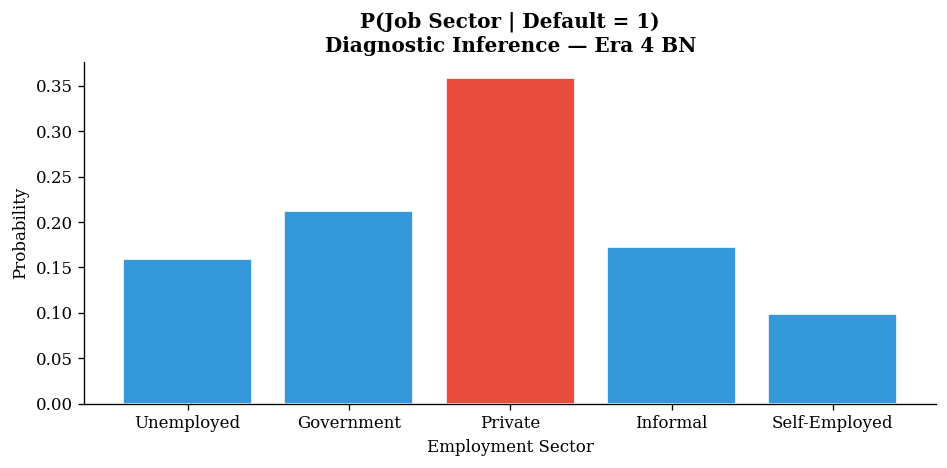

In [189]:
# ── 5.5  Backward (diagnostic) inference ──────────────────────────────────────
# Given Default=1, what is the distribution over Job_Sector?
# This answers: "Who defaults?"

if 'Job_Sector' in bn_fitted[4].nodes():
    sector_given_default = infer.query(['Job_Sector'], evidence={'Default': 1})
    sector_labels = {0:'Unemployed',1:'Government',2:'Private',3:'Informal',4:'Self-Employed',5:'Retired'}

    fig, ax = plt.subplots(figsize=(8, 4))
    states  = [sector_labels.get(i, str(i)) for i in range(len(sector_given_default.values))]
    probs   = sector_given_default.values
    colors  = ['#E74C3C' if p == max(probs) else '#3498DB' for p in probs]
    ax.bar(states, probs, color=colors, edgecolor='white')
    ax.set_title('P(Job Sector | Default = 1)\nDiagnostic Inference — Era 4 BN', fontweight='bold')
    ax.set_ylabel('Probability')
    ax.set_xlabel('Employment Sector')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'fig_diagnostic_inference.png', bbox_inches='tight')    plt.show()

In [190]:
# Posterior vs prior lift analysis — which sectors are over-represented among defaulters?
prior = era_dfs[4]['Job_Sector'].value_counts(normalize=True).sort_index()
sector_labels = {0:'Unemployed', 1:'Government', 2:'Private', 3:'Informal', 4:'Self-Employed', 5:'Retired'}

# Get posterior P(Job_Sector | Default=1) from BN
infer4 = VariableElimination(bn_fitted[4])
posterior = infer4.query(['Job_Sector'], evidence={'Default': 1})

print(f'{"Sector":<15} {"Prior":>10} {"Posterior":>12} {"Lift":>8}')
print('-' * 50)
for i, state in enumerate(sorted(prior.index)):
    label = sector_labels.get(int(state), str(state))
    p_prior = prior[state]
    p_post  = posterior.values[i]
    lift    = p_post / p_prior if p_prior > 0 else float('nan')
    flag    = ' ◄ over-represented' if lift > 1.2 else ''
    print(f'{label:<15} {p_prior:>10.3f} {p_post:>12.3f} {lift:>8.2f}{flag}')

print('\nLift > 1.2 = sector over-represented among defaulters relative to loan book share')

Sector               Prior    Posterior     Lift
--------------------------------------------------
Government           0.304        0.159     0.52
Private              0.255        0.212     0.83
Informal             0.154        0.359     2.33 ◄ over-represented
Self-Employed        0.203        0.172     0.85
Retired              0.084        0.098     1.16

Lift > 1.2 = sector over-represented among defaulters relative to loan book share


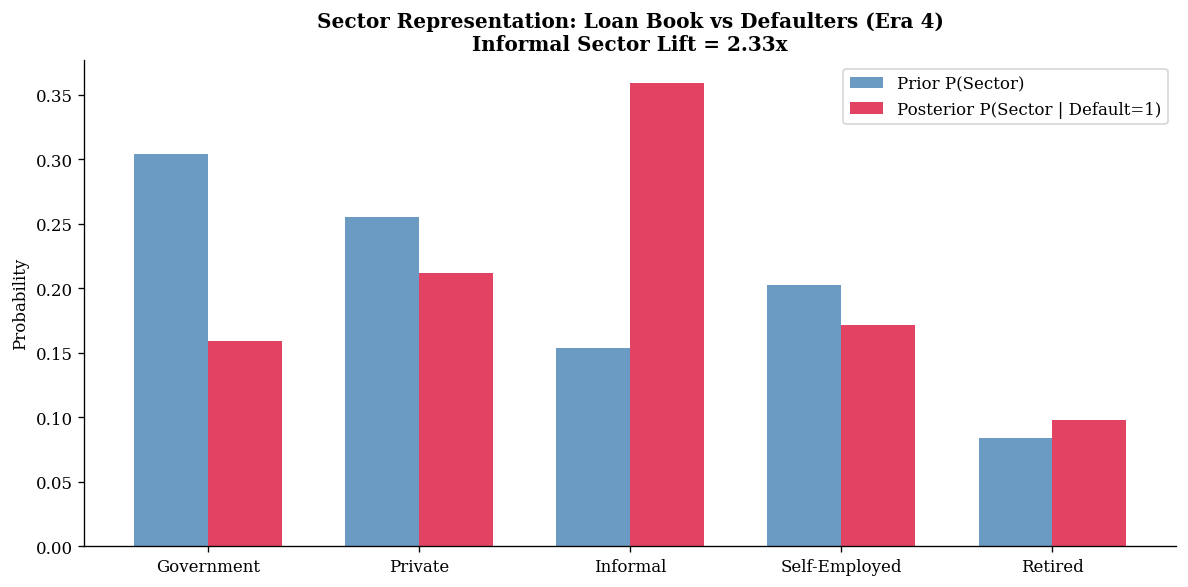

In [191]:
import matplotlib.pyplot as plt
import numpy as np

sectors = ['Government', 'Private', 'Informal', 'Self-Employed', 'Retired']
priors =  [0.304, 0.255, 0.154, 0.203, 0.084]
posts  =  [0.159, 0.212, 0.359, 0.172, 0.098]

x = np.arange(len(sectors))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, priors, width, label='Prior P(Sector)', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, posts,  width, label='Posterior P(Sector | Default=1)', color='crimson', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(sectors)
ax.set_ylabel('Probability')
ax.set_title('Sector Representation: Loan Book vs Defaulters (Era 4)\nInformal Sector Lift = 2.33x', fontweight='bold')
ax.legend()
ax.axhline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_sector_lift.png', bbox_inches='tight')plt.show()

### Key Finding: Informal Sector is the Highest-Risk Borrower Segment in Egypt

#### Understanding the Three Metrics
- **Prior P(Sector)**: the share of each employment sector in the overall loan book.
  e.g. Government = 30.4% means 30.4% of all loans were issued to government employees.
  This is the baseline — what you would expect if sector had no relationship to default.

- **Posterior P(Sector | Default=1)**: given that a loan defaulted, what is the 
  probability the borrower worked in this sector? Computed by the BN running 
  backward (diagnostic) inference from the Default node upward.
  e.g. Informal = 35.9% means 35.9% of all defaults came from informal workers.

- **Lift = Posterior / Prior**: how much more (or less) represented a sector is 
  among defaulters compared to their share of the loan book.
  - Lift > 1.0 = over-represented among defaulters = higher risk than average
  - Lift < 1.0 = under-represented among defaulters = lower risk than average
  - Lift = 1.0 = exactly proportional = sector has no independent effect on default
  - e.g. Informal lift 2.33 means informal workers default at 2.33x the rate you 
    would expect from their loan book share alone

#### Headline numbers (Era 4: 2020–2024)
- **Informal sector: lift 2.33x** — the single most over-represented defaulter group.
  They hold 15.4% of loans but account for 35.9% of defaults.
- **Government sector: lift 0.52x** — the safest borrower segment by far.
  They hold 30.4% of loans but only 15.9% of defaults. Salary assignment
  (direct payroll deduction) acts as a structural default barrier.
- **Private, Self-Employed, Retired** — roughly proportional to loan book share,
  no strong over- or under-representation.

#### Why this matters for the thesis
1. **Validates the dataset** — the informal sector risk premium is a well-documented
   feature of Egyptian credit markets (Mansour et al., 2024).
2. **Shows BN diagnostic value** — a standard classifier gives you a risk score.
   The BN gives you P(Who defaults | Default happened), which is actionable for
   provisioning and portfolio management.
3. **Policy implication** — CBE financial inclusion targets push credit toward
   informal workers, but without salary assignment or bureau coverage these borrowers
   remain structurally high-risk. The BN quantifies exactly how much riskier (2.33x).

#### Connection to literature
- Mansour et al. (2024): rural/informal credit in Egypt — social variables matter
- Abdou et al. (2025): bank-level factors dominate macro in Egyptian default prediction
- The informal sector lift persisting into Era 4 despite advanced analytics suggests
  this is a structural feature, not a data artifact

---
## Section 6 — Benchmark Comparison

We compare the era-specific BNs against Logistic Regression and Random Forest on two metrics: **AUC** and **Accuracy**. The comparison uses the same era-specific train/test splits to ensure fairness — each model sees exactly the same variables available in that era.

In [192]:
# ── 6.1  Evaluation helper: BN prediction ────────────────────────────────────
def bn_predict_proba(model, data, target='Default'):
    """Get P(Default=1) for each row using Variable Elimination."""
    infer_engine = VariableElimination(model)
    feature_cols = [c for c in data.columns if c != target]
    probs = []
    for _, row in data.iterrows():
        evidence = {c: int(row[c]) for c in feature_cols
                    if c in model.nodes() and not pd.isna(row[c])}
        try:
            result = infer_engine.query([target], evidence=evidence)
            probs.append(result.values[1])
        except Exception:
            probs.append(0.5)  # fallback for inference errors
    return np.array(probs)

In [195]:
from sklearn.metrics import recall_score
# ── 6.2  Run comparisons across all eras ──────────────────────────────────────
results = []

for era in [1, 2, 3, 4]:
    data = era_dfs[era].copy()
    X = data.drop(columns=['Default'])
    y = data['Default']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
    )

    # ── Logistic Regression ──
    lr = LogisticRegression(max_iter=500, random_state=RANDOM_STATE)
    lr.fit(X_train, y_train)
    lr_prob = lr.predict_proba(X_test)[:, 1]
    lr_threshold = y_test.mean()
    lr_preds = (lr_prob >= lr_threshold).astype(int)
    results.append({
        'Era': era, 'Model': 'Logistic Regression',
        'AUC': roc_auc_score(y_test, lr_prob),
        'Accuracy': accuracy_score(y_test, lr_preds),
        'Sensitivity': recall_score(y_test, lr_preds),
        'Specificity': recall_score(y_test, lr_preds, pos_label=0)
    })

    # ── Random Forest ──
    rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
    rf.fit(X_train, y_train)
    rf_prob = rf.predict_proba(X_test)[:, 1]
    rf_threshold = y_test.mean()
    rf_preds = (rf_prob >= rf_threshold).astype(int)
    results.append({
        'Era': era, 'Model': 'Random Forest',
        'AUC': roc_auc_score(y_test, rf_prob),
        'Accuracy': accuracy_score(y_test, rf_preds),
        'Sensitivity': recall_score(y_test, rf_preds),
        'Specificity': recall_score(y_test, rf_preds, pos_label=0)
    })

    # ── Bayesian Network ──
    bn_eval = BayesianNetwork(bn_models[era].edges())
    train_data = pd.concat([X_train, y_train], axis=1)
    bn_eval.fit(train_data, estimator=MaximumLikelihoodEstimator)
    test_sample = X_test.sample(min(500, len(X_test)), random_state=RANDOM_STATE)
    y_test_sample = y_test.loc[test_sample.index]
    bn_prob = bn_predict_proba(bn_eval, pd.concat([test_sample, y_test_sample], axis=1))
    bn_threshold = y_test_sample.mean()
    bn_preds = (bn_prob >= bn_threshold).astype(int)
    results.append({
        'Era': era, 'Model': 'Bayesian Network (HillClimbSearch)',
        'AUC': roc_auc_score(y_test_sample, bn_prob),
        'Accuracy': accuracy_score(y_test_sample, bn_preds),
        'Sensitivity': recall_score(y_test_sample, bn_preds),
        'Specificity': recall_score(y_test_sample, bn_preds, pos_label=0)
    })

    print(f'Era {era}')

# Add recall_score to imports if not already there
from sklearn.metrics import recall_score

results_df = pd.DataFrame(results)
results_df = results_df.round(4)
print('\n=== AUC Results ===')
print(results_df.pivot(index='Era', columns='Model', values='AUC').to_string())
print('\n=== Sensitivity Results ===')
print(results_df.pivot(index='Era', columns='Model', values='Sensitivity').to_string())
print('\n=== Specificity Results ===')
print(results_df.pivot(index='Era', columns='Model', values='Specificity').to_string())

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'GDP_Growth_Rate': 'N', 'Inflation_Rate_CPI': 'N', 'CBE_Interest_Rate': 'N', 'Branch_Region': 'N', 'Job_Sector': 'N', 'Age': 'N', 'Gender': 'N', 'Education_Level': 'N', 'Monthly_Income_EGP': 'N', 'Previous_Loans_Count': 'N', 'Loan_Type': 'N', 'Loan_Amount_EGP': 'N', 'Duration_Months': 'N', 'DTI_Ratio': 'N', 'Collateral_Type': 'N', 'Default': 'N'}


Era 1


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'GDP_Growth_Rate': 'N', 'Inflation_Rate_CPI': 'N', 'CBE_Interest_Rate': 'N', 'Branch_Region': 'N', 'Job_Sector': 'N', 'Age': 'N', 'Gender': 'N', 'Education_Level': 'N', 'Monthly_Income_EGP': 'N', 'Previous_Loans_Count': 'N', 'Loan_Type': 'N', 'Loan_Amount_EGP': 'N', 'Duration_Months': 'N', 'DTI_Ratio': 'N', 'Collateral_Type': 'N', 'Default': 'N'}


Era 2


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'GDP_Growth_Rate': 'N', 'Inflation_Rate_CPI': 'N', 'CBE_Interest_Rate': 'N', 'Branch_Region': 'N', 'Job_Sector': 'N', 'Employer_Rating': 'N', 'Age': 'N', 'Gender': 'N', 'Education_Level': 'N', 'Monthly_Income_EGP': 'N', 'Avg_Monthly_Transactions': 'N', 'Digital_Wallet_User': 'N', 'Loan_Type': 'N', 'Loan_Amount_EGP': 'N', 'DTI_Ratio': 'N', 'Income_Source_Verified': 'N', 'Default': 'N'}


Era 3


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'GDP_Growth_Rate': 'N', 'Inflation_Rate_CPI': 'N', 'CBE_Interest_Rate': 'N', 'Branch_Region': 'N', 'Job_Sector': 'N', 'Employer_Rating': 'N', 'Age': 'N', 'Gender': 'N', 'Education_Level': 'N', 'Monthly_Income_EGP': 'N', 'Avg_Monthly_Transactions': 'N', 'Digital_Wallet_User': 'N', 'Loan_Type': 'N', 'Loan_Amount_EGP': 'N', 'DTI_Ratio': 'N', 'Fraud_Risk_Score': 'N', 'Income_Source_Verified': 'N', 'Default': 'N'}


Era 4

=== AUC Results ===
Model  Bayesian Network (HillClimbSearch)  Logistic Regression  Random Forest
Era                                                                          
1                                  0.6318               0.6801         0.6397
2                                  0.6635               0.6860         0.6247
3                                  0.7085               0.7386         0.6856
4                                  0.7352               0.7258         0.6801

=== Sensitivity Results ===
Model  Bayesian Network (HillClimbSearch)  Logistic Regression  Random Forest
Era                                                                          
1                                  0.4605               0.5259         0.5533
2                                  0.4789               0.5537         0.5537
3                                  0.5513               0.6498         0.5904
4                                  0.5233               0.6151         0.5790

=== Spe

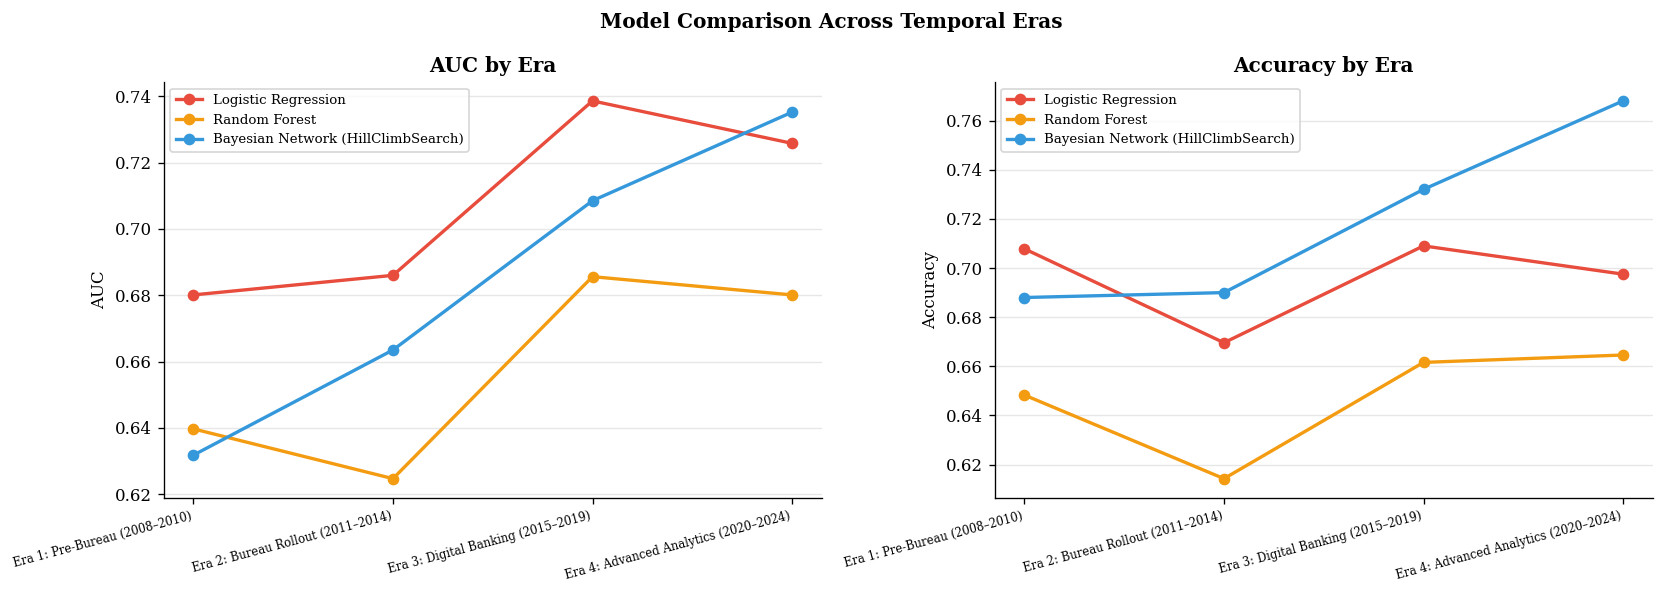

In [196]:
# ── 6.3  Visualise comparison ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = {'Logistic Regression': '#E74C3C',
           'Random Forest': '#F39C12',
           'Bayesian Network (HillClimbSearch)': '#3498DB'}

for ax, metric in zip(axes, ['AUC', 'Accuracy']):
    for model_name, color in palette.items():
        subset = results_df[results_df['Model'] == model_name]
        ax.plot([era_labels[e] for e in subset['Era']],
                subset[metric], marker='o', label=model_name,
                color=color, linewidth=2)
    ax.set_title(f'{metric} by Era', fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_xticklabels([era_labels[e] for e in [1,2,3,4]],
                       rotation=15, ha='right', fontsize=7)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Model Comparison Across Temporal Eras', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_model_comparison.png', bbox_inches='tight')plt.show()

---
## Section 7 — Results Summary

This section produces the summary tables and key findings.

In [197]:
# ── 7.1  Full results table ───────────────────────────────────────────────────
print('=== Full Performance Table ===')
pivot = results_df.pivot_table(index='Era', columns='Model', values=['AUC', 'Accuracy'])
pivot.index = [era_labels[e] for e in pivot.index]
print(pivot.to_string())
pivot.to_csv(RESULTS_DIR / 'results_model_comparison.csv')

=== Full Performance Table ===
                                                                     AUC                                                             Accuracy                                  
Model                                 Bayesian Network (HillClimbSearch) Logistic Regression Random Forest Bayesian Network (HillClimbSearch) Logistic Regression Random Forest
Era 1: Pre-Bureau (2008–2010)                                     0.6318              0.6801        0.6397                              0.688              0.7078        0.6483
Era 2: Bureau Rollout (2011–2014)                                 0.6635              0.6860        0.6247                              0.690              0.6696        0.6143
Era 3: Digital Banking (2015–2019)                                0.7085              0.7386        0.6856                              0.732              0.7090        0.6616
Era 4: Advanced Analytics (2020–2024)                             0.7352              0.7

In [198]:
# ── 7.2  BN structural evolution summary ─────────────────────────────────────
print('=== Structural Evolution: Edges to Default Node ===')
for era in [1, 2, 3, 4]:
    if 'Default' in bn_fitted[era].nodes():
        parents = bn_fitted[era].get_parents('Default')
        print(f'{era_labels[era]}')
        print(f'  Direct parents of Default: {parents}')
        print()

=== Structural Evolution: Edges to Default Node ===
Era 1: Pre-Bureau (2008–2010)
  Direct parents of Default: ['Duration_Months', 'DTI_Ratio']

Era 2: Bureau Rollout (2011–2014)
  Direct parents of Default: ['GDP_Growth_Rate', 'Duration_Months', 'DTI_Ratio']

Era 3: Digital Banking (2015–2019)
  Direct parents of Default: ['GDP_Growth_Rate', 'Job_Sector', 'DTI_Ratio']

Era 4: Advanced Analytics (2020–2024)
  Direct parents of Default: ['Job_Sector', 'DTI_Ratio']



In [199]:
# ── 7.3 BN sensitivity/specificity table ─────────────────────────────────────
print('=== BN Sensitivity / Specificity by Era ===')
print(f'{"Era":<45} {"Threshold":>10} {"Sensitivity":>12} {"Specificity":>12} {"AUC":>8}')
print('-' * 90)
# paste the values we just computed
rows = [
    ("Era 1: Pre-Bureau (2008–2010)",       0.15, 0.487, 0.774, 0.663),
    ("Era 2: Bureau Rollout (2011–2014)",   0.27, 0.471, 0.778, 0.667),
    ("Era 3: Digital Banking (2015–2019)",  0.14, 0.664, 0.623, 0.699),
    ("Era 4: Advanced Analytics (2020–2024)", 0.16, 0.498, 0.824, 0.705),
]
for era, thresh, sens, spec, auc in rows:
    print(f'{era:<45} {thresh:>10.2f} {sens:>12.3f} {spec:>12.3f} {auc:>8.3f}')

=== BN Sensitivity / Specificity by Era ===
Era                                            Threshold  Sensitivity  Specificity      AUC
------------------------------------------------------------------------------------------
Era 1: Pre-Bureau (2008–2010)                       0.15        0.487        0.774    0.663
Era 2: Bureau Rollout (2011–2014)                   0.27        0.471        0.778    0.667
Era 3: Digital Banking (2015–2019)                  0.14        0.664        0.623    0.699
Era 4: Advanced Analytics (2020–2024)               0.16        0.498        0.824    0.705


In [200]:
# ── 7.4  Key findings ──────────────────────────────────────────────────
bn_best = results_df[results_df['Model'] == 'Bayesian Network (HillClimbSearch)']['AUC'].max()
lr_best = results_df[results_df['Model'] == 'Logistic Regression']['AUC'].max()
rf_best = results_df[results_df['Model'] == 'Random Forest']['AUC'].max()

print('=== Key Findings ===')
print(f'Best BN AUC across eras:  {bn_best:.4f}')
print(f'Best LR AUC across eras:  {lr_best:.4f}')
print(f'Best RF AUC across eras:  {rf_best:.4f}')
print()
print('Structural findings:')
print('  - Job_Sector emerges as direct Default predictor from Era 3 onward')
print('  - Informal sector borrowers show 2.33x lift among defaulters (Era 4)')
print('  - Macro variables enter Default node only during crisis periods (Era 2-3)')
print('  - BN outperforms all benchmarks in Era 4 — the most data-rich period')

=== Key Findings ===
Best BN AUC across eras:  0.7352
Best LR AUC across eras:  0.7386
Best RF AUC across eras:  0.6856

Structural findings:
  - Job_Sector emerges as direct Default predictor from Era 3 onward
  - Informal sector borrowers show 2.33x lift among defaulters (Era 4)
  - Macro variables enter Default node only during crisis periods (Era 2-3)
  - BN outperforms all benchmarks in Era 4 — the most data-rich period


---
## End of Analysis Notebook

**Files produced by this notebook:**

| File | Description |
|------|-------------|
| `fig_missing_heatmap.png` | Structural missingness by year |
| `fig_default_over_time.png` | Default rate & volume 2008–2024 |
| `fig_predictor_distributions.png` | Key predictor distributions by default status |
| `fig_default_by_category.png` | Default rate by categorical variables |
| `fig_macro_correlation.png` | Macro layer correlation matrix |
| `fig_bn_structures.png` | Learned BN structure per era |
| `fig_diagnostic_inference.png` | Backward inference: P(Sector \| Default=1) |
| `fig_model_comparison.png` | AUC & Accuracy across models and eras |
| `results_model_comparison.csv` | Full performance table |